In [46]:
import os
import pickle
import numpy as np
import os.path as osp
from tqdm import tqdm
from pprint import pprint
from datetime import datetime
from typing import List
import matplotlib.pyplot as plt

import torch
import tensorflow as tf
from tensorflow.keras import losses
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import load_model


from src.models import CNNtf
import src.cf_methods.countergan.utils  as cutils
from src.cf_methods.countergan import create_convolutional_autoencoder

tf.experimental.numpy.experimental_enable_numpy_behavior()

plt.style.use('seaborn-v0_8-darkgrid')

In [47]:
from src.utils import seed_tf

seed_tf()

Loading MNIST data

In [48]:
DESIRED_CLASS = 8  # This is the target class that the generator will learn to synthetize
N_CLASSES = 10

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = (x_train / 255.).astype("float32")
x_test = (x_test / 255.).astype("float32")

In [49]:
def get_factual_instances(x: np.ndarray, y: np.ndarray, class_indices: List[int], set_new_ind=False):
    labels = []
    factuals = []
    for new_ind, class_ind in enumerate(class_indices):
        class_mask = (y == class_ind)
        if set_new_ind:
            labels.extend(y[class_mask].shape[0]* [new_ind])
        else:
            labels.extend(y[class_mask])
        factuals.extend(x[class_mask])
    indices = np.arange(len(labels))
    np.random.shuffle(indices)
    factuals, labels = np.array(factuals), np.array(labels)
    factuals = factuals[indices]
    labels = labels[indices]
    return factuals, labels

In [50]:
factual_classes = [0, 3, 4, 5, 8, 9]
x_train_red, y_train_red = get_factual_instances(x_train, y_train, factual_classes)
x_test_red, y_test_red = get_factual_instances(x_test, y_test, factual_classes)


In [51]:
X_train = tf.expand_dims(x_train_red, axis=-1)
X_test = tf.expand_dims(x_test_red, axis=-1)

y_train_encoded = to_categorical(y_train_red, N_CLASSES)
y_test_encoded = to_categorical(y_test_red, N_CLASSES)

## Train AE

In [ ]:
def add_noise(x, noise_factor=0.5):
    noise_factor = 0.5
    x_noisy = x + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x.shape)
    x_noisy = np.clip(x_noisy, 0., 1.)
    return x_noisy

autoencoder = create_convolutional_autoencoder(in_shape=(28, 28, 1))
training = autoencoder.fit(
    add_noise(X_train), X_train, epochs=15, batch_size=128, shuffle=True,
    verbose=1, validation_data=(X_test, X_test)
)
print(f"Training loss: {training.history['loss'][-1]:.4f}")
print(f"Validation loss: {training.history['val_loss'][-1]:.4f}")

# Compute the reconstruction error of noise data
samples = np.random.uniform(low=0.0, high=1.0, size=(1000, 28, 28, 1))
reconstruction_error_noise = cutils.compute_reconstruction_error(samples, autoencoder)

# Save and print the autoencoder metrics
reconstruction_error = cutils.compute_reconstruction_error(X_test, autoencoder)
autoencoder_metrics = {
    "reconstruction_error": cutils.format_metric(reconstruction_error),
    "reconstruction_error_noise": cutils.format_metric(reconstruction_error_noise),
}

pprint(autoencoder_metrics)


Epoch 1/15
188/188 [==============================] - 22s 115ms/step - loss: 0.0340 - val_loss: 0.0199
Epoch 2/15
188/188 [==============================] - 22s 118ms/step - loss: 0.0208 - val_loss: 0.0180
Epoch 3/15
188/188 [==============================] - 22s 120ms/step - loss: 0.0191 - val_loss: 0.0159
Epoch 4/15
188/188 [==============================] - 24s 129ms/step - loss: 0.0181 - val_loss: 0.0156
Epoch 5/15
188/188 [==============================] - 27s 145ms/step - loss: 0.0175 - val_loss: 0.0158
Epoch 6/15
188/188 [==============================] - 31s 165ms/step - loss: 0.0170 - val_loss: 0.0148
Epoch 7/15
188/188 [==============================] - 30s 161ms/step - loss: 0.0166 - val_loss: 0.0143
Epoch 8/15
188/188 [==============================] - 31s 165ms/step - loss: 0.0162 - val_loss: 0.0135
Epoch 9/15
188/188 [==============================] - 31s 165ms/step - loss: 0.0160 - val_loss: 0.0133
Epoch 10/15
188/188 [==============================] - 29s 152ms/step - l

In [ ]:
weights_path = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_ae'
file_name = 'autoencoder_mnist.h5'
autoencoder.save(osp.join(weights_path, file_name))


d:\PycharmProjects\CF-Robustness-Benchmark\venv\Lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


## Load a classifier and AE

Load classifier

In [52]:
saved_model_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_classification\multi\checkpoints'
file_name = 'classifier_mnist.keras'

baseline_classifier = load_model(osp.join(saved_model_dir, file_name), 
                        custom_objects={'CNNtf': CNNtf})

y_prob = baseline_classifier.predict(X_test)

accuracy = (y_prob.argmax(axis=1) == tf.argmax(y_test_encoded, axis=1)).mean()
print(f"Classifier accuracy test: {accuracy:.3%}")

183/183 [==============================] - 1s 7ms/step
Classifier accuracy test: 98.204%


Load AE

In [53]:
weights_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_ae'
autoencoder = load_model(osp.join(weights_dir, "autoencoder.h5"),
                             custom_objects={'mse': losses.mse})
reconstruction_error_test = cutils.compute_reconstruction_error(X_test, autoencoder)
print(f"AE average reconstruction error: {reconstruction_error_test.mean():.3f}")

AE average reconstruction error: 3.875


# Training of CounterGAN

In [11]:
from src.cf_methods.countergan import create_generator, create_discriminator, define_countergan

In [12]:

save_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_multi\visualizations'
models_save_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_multi\checkpoints'

os.makedirs(save_dir, exist_ok=True)
os.makedirs(models_save_dir, exist_ok=True)

In [ ]:
generator = create_generator(in_shape=(28, 28, 1))
discriminator = create_discriminator(in_shape=(28, 28, 1))

In [ ]:
# class_encodings = {factual_cls: i for i, factual_cls in enumerate(factual_classes)}

def train_countergan(n_discriminator_steps, n_generator_steps, n_training_iterations,
                     classifier, discriminator, generator, batches,
                     weighted_version=False, negative_batches=None, positive_batches=None,
                     ):
    """ Main function: train the CounteRGAN"""

    def check_divergence(x_generated):
        return np.all(np.isnan(x_generated))

    def print_training_information(generator, classifier, X_test, iteration):
        X_gen = generator.predict(X_test)
        clf_pred_test = classifier.predict(X_test) # y_M 
        clf_pred = classifier.predict(X_gen)  # y_cf

        delta_clf_pred = (clf_pred - clf_pred_test)[:, DESIRED_CLASS]
        y_target = to_categorical([DESIRED_CLASS] * len(clf_pred), num_classes=N_CLASSES)
        print('='*88)
        print(f"Training iteration {iteration} at {datetime.now()}")

        # Plot original images, residuals, and generated images
        sample_indices  = np.random.choice(len(X_test), 10, replace=False)
        residuals = X_gen[sample_indices]-X_test[sample_indices]

        cutils.plot_generated_images(X_test[sample_indices], n_plots=10, n_plots_per_row=10, save_path=osp.join(save_dir, f'original_images_iter_{iteration}.png'))
        cutils.plot_generated_images(residuals, n_plots=10, n_plots_per_row=10, residuals=True, save_path=osp.join(save_dir, f'residuals_iter_{iteration}.png'))
        cutils.plot_generated_images(X_gen[sample_indices], n_plots=10, n_plots_per_row=10, save_path=osp.join(save_dir, f'generated_images_iter_{iteration}.png'))

        reconstruction_error = np.mean(cutils.compute_reconstruction_error(X_gen, autoencoder))
        print(f"Autoencoder reconstruction error (infinity to 0): {reconstruction_error:.3f}")
        print(f"Counterfactual prediction gain (0 to 1): {delta_clf_pred.mean():.3f}")
        print(f"Sparsity (L1, infinity to 0): {np.mean(np.abs(X_gen-X_test)):.3f}")


    countergan = define_countergan(generator, discriminator, classifier)

    for iteration in tqdm(range(n_training_iterations)):
        # Periodically print and plot training information
        if (iteration % 300 == 0) or (iteration == n_training_iterations - 1):
            print_training_information(generator, classifier, X_test, iteration)
            generator.save(osp.join(models_save_dir, f'generator_target7_iter_{iteration}.keras'))
            discriminator.save(osp.join(models_save_dir, f'discriminator_target7_iter_{iteration}.keras'))

        # Train the discriminator
        discriminator.trainable = True
        for _ in range(n_discriminator_steps):
            x_fake_input, _ = next(batches)
            x_real = x_fake_input

            x_fake = cutils.generate_fake_samples(x_fake_input, generator)

            x_batch = np.concatenate([x_real, x_fake])
            y_batch = np.concatenate([np.ones(len(x_real)), np.zeros(len(x_fake))])

            # Shuffle real and fake examples
            p = np.random.permutation(len(y_batch))
            x_batch, y_batch = x_batch[p], y_batch[p]
            discriminator.train_on_batch(x_batch, y_batch)

        # Train the generator
        discriminator.trainable = False
        for _ in range(n_generator_steps):
            x_fake_input, _ = next(batches)
            y_fake = np.ones(len(x_fake_input))
            y_target = to_categorical([DESIRED_CLASS] * len(x_fake_input),
                                          num_classes=N_CLASSES)
            
            #print(x_fake_input.shape, x_fake_input.dtype)
            #print(y_fake.shape, y_target.shape)
            countergan.train_on_batch(x_fake_input, [y_fake, y_target])
    
    return countergan

In [ ]:
batches = cutils.infinite_data_stream(X_train, y_train_encoded, batch_size=128)

  0%|          | 0/5000 [00:00<?, ?it/s]

126/126 [==============================] - 0s 3ms/step
Training iteration 0 at 2025-06-22 13:40:40.594645


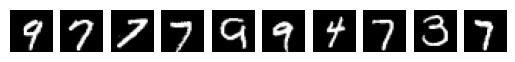

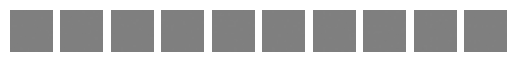

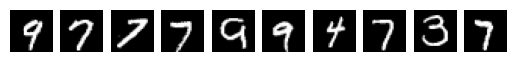

Autoencoder reconstruction error (infinity to 0): 3.623
Counterfactual prediction gain (0 to 1): 0.000
Sparsity (L1, infinity to 0): 0.002


  6%|▌         | 300/5000 [09:03<2:17:30,  1.76s/it]

126/126 [==============================] - 0s 3ms/step
Training iteration 300 at 2025-06-22 13:49:42.363277


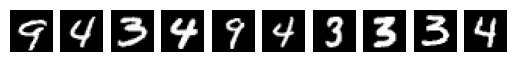

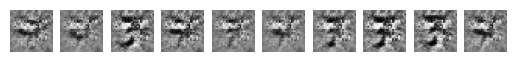

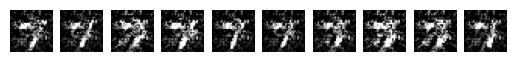

Autoencoder reconstruction error (infinity to 0): 7.951
Counterfactual prediction gain (0 to 1): 0.752
Sparsity (L1, infinity to 0): 0.232


 12%|█▏        | 600/5000 [18:10<2:14:37,  1.84s/it]

126/126 [==============================] - 0s 3ms/step
Training iteration 600 at 2025-06-22 13:58:49.771054


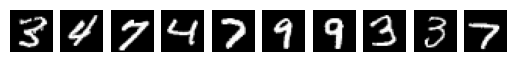

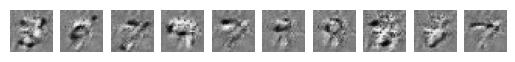

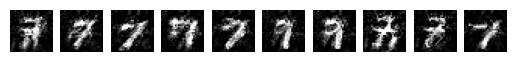

Autoencoder reconstruction error (infinity to 0): 5.917
Counterfactual prediction gain (0 to 1): 0.750
Sparsity (L1, infinity to 0): 0.165


 18%|█▊        | 900/5000 [27:24<2:08:05,  1.87s/it]

126/126 [==============================] - 0s 3ms/step
Training iteration 900 at 2025-06-22 14:08:03.753430


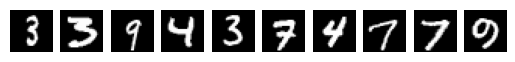

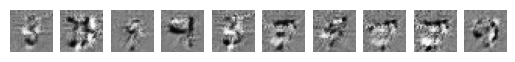

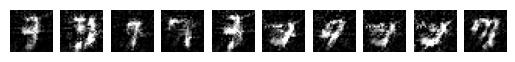

Autoencoder reconstruction error (infinity to 0): 5.607
Counterfactual prediction gain (0 to 1): 0.744
Sparsity (L1, infinity to 0): 0.164


 24%|██▍       | 1200/5000 [37:14<2:08:37,  2.03s/it]

126/126 [==============================] - 1s 4ms/step
Training iteration 1200 at 2025-06-22 14:17:54.341207


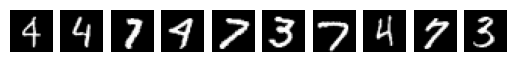

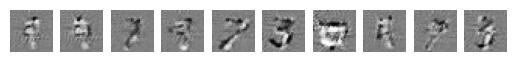

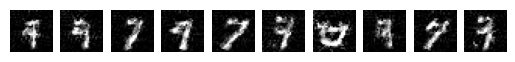

Autoencoder reconstruction error (infinity to 0): 5.250
Counterfactual prediction gain (0 to 1): 0.725
Sparsity (L1, infinity to 0): 0.141


 30%|███       | 1500/5000 [47:43<2:10:36,  2.24s/it]

126/126 [==============================] - 1s 5ms/step
Training iteration 1500 at 2025-06-22 14:28:23.172835


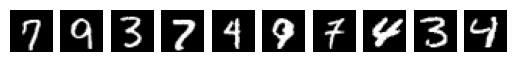

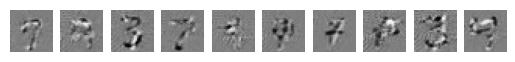

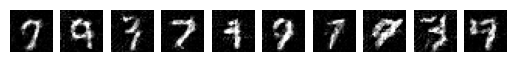

Autoencoder reconstruction error (infinity to 0): 4.630
Counterfactual prediction gain (0 to 1): 0.715
Sparsity (L1, infinity to 0): 0.121


 36%|███▌      | 1800/5000 [1:02:09<4:04:41,  4.59s/it]

126/126 [==============================] - 1s 11ms/step
Training iteration 1800 at 2025-06-22 14:42:59.298900


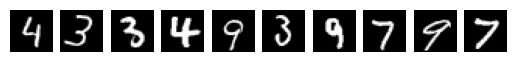

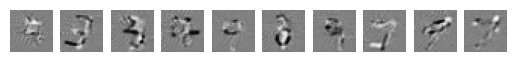

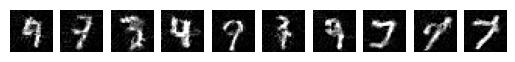

Autoencoder reconstruction error (infinity to 0): 4.408
Counterfactual prediction gain (0 to 1): 0.700
Sparsity (L1, infinity to 0): 0.109


 42%|████▏     | 2100/5000 [1:23:21<3:22:16,  4.18s/it]

126/126 [==============================] - 1s 10ms/step
Training iteration 2100 at 2025-06-22 15:04:08.967908


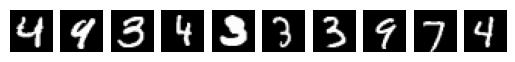

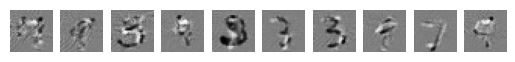

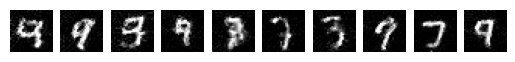

Autoencoder reconstruction error (infinity to 0): 4.243
Counterfactual prediction gain (0 to 1): 0.668
Sparsity (L1, infinity to 0): 0.101


 48%|████▊     | 2400/5000 [1:48:51<4:09:31,  5.76s/it]

126/126 [==============================] - 2s 12ms/step
Training iteration 2400 at 2025-06-22 15:29:41.015623


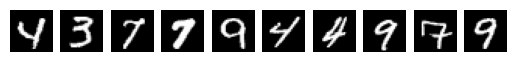

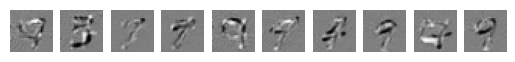

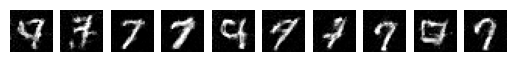

Autoencoder reconstruction error (infinity to 0): 4.177
Counterfactual prediction gain (0 to 1): 0.684
Sparsity (L1, infinity to 0): 0.102


 54%|█████▍    | 2700/5000 [2:11:33<2:52:26,  4.50s/it]

126/126 [==============================] - 1s 6ms/step
Training iteration 2700 at 2025-06-22 15:52:16.775391


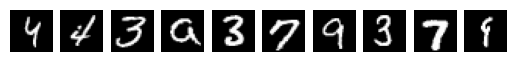

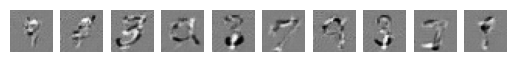

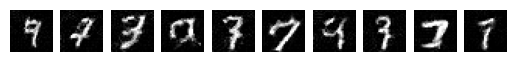

Autoencoder reconstruction error (infinity to 0): 4.193
Counterfactual prediction gain (0 to 1): 0.678
Sparsity (L1, infinity to 0): 0.097


 60%|██████    | 3000/5000 [2:32:46<2:18:15,  4.15s/it]

126/126 [==============================] - 1s 6ms/step
Training iteration 3000 at 2025-06-22 16:13:28.701046


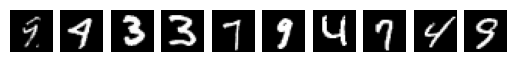

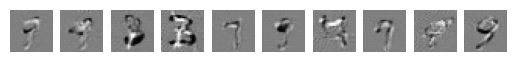

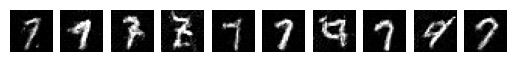

Autoencoder reconstruction error (infinity to 0): 4.093
Counterfactual prediction gain (0 to 1): 0.673
Sparsity (L1, infinity to 0): 0.094


 66%|██████▌   | 3300/5000 [3:01:10<2:09:02,  4.55s/it]

126/126 [==============================] - 1s 6ms/step
Training iteration 3300 at 2025-06-22 16:41:53.601976


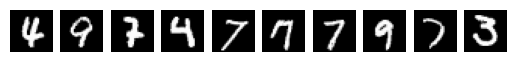

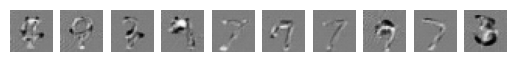

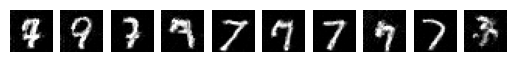

Autoencoder reconstruction error (infinity to 0): 4.082
Counterfactual prediction gain (0 to 1): 0.661
Sparsity (L1, infinity to 0): 0.090


 66%|██████▌   | 3304/5000 [3:01:45<1:33:17,  3.30s/it]


KeyboardInterrupt: 

In [ ]:
method_name = "countergan"
countergan = train_countergan(2, 3, 5000, baseline_classifier, discriminator, generator, batches)

# Evaluation of CounterGAN

Load perts of CounteRGAN

In [54]:
models_save_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_multi\checkpoints_8'

generator_fname = 'generator_target8_iter_2500.keras' #'generator_target7_iter_3300.keras'
discriminator_fname = 'discriminator_target8_iter_2500.keras' #'discriminator_target7_iter_3300.keras'

generator = load_model(osp.join(models_save_dir, generator_fname))
discriminator = load_model(osp.join(models_save_dir, discriminator_fname))

In [55]:
factuals, labels = [], []

for class_ind in [0, 3, 4, 5, 9]:
    indices = np.where(y_test == class_ind)[0]
    factuals.extend(x_test[indices])
    labels.extend([class_ind] * len(indices))
factuals = np.asarray(factuals)
labels = np.asarray(labels)

shuffled_indices = tf.random.shuffle(tf.range(labels.shape[0]))  # Generate shuffled indices
labels = tf.gather(labels, shuffled_indices)  # Reorder labels

# Shuffle images if needed to align with new label order
factuals = tf.expand_dims(tf.gather(factuals, shuffled_indices), axis=-1)
print('Total number of factual instances: ', factuals.shape[0])

Total number of factual instances:  4873


In [56]:
predictions = tf.argmax(baseline_classifier.predict(factuals, verbose=0), axis=1)
_, valid_indices = np.where([predictions == labels])

In [57]:
factuals = tf.gather(factuals, valid_indices)
labels = tf.gather(labels, valid_indices) 

## Robustness Evaluation

### Local Instability

In [58]:
from functools import reduce
from src.evaluation.local_instability import perturb_sample
from src.evaluation.local_instability import calculate_sparsity, calculate_ssim
from src.utils.visualization import plot_boxplot

In [59]:
cfes = generator.predict(factuals, verbose=0)

In [60]:
noise_levels = [0.005, 0.01, 0.015, 0.02, 0.025]
# noise_levels = [0.001, 0.0025, 0.005, 0.0075, 0.01]
output_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\cf_output\mnist\countergan_multi'

In [61]:
factuals_pert = {}
pert_indices = {}

for noise_level in noise_levels:
    pert_sample = perturb_sample(factuals, n_samples=1, epsilon=noise_level, 
                                 type='uniform', channels_first=False)
    pert_sample = pert_sample.squeeze(1)
    factuals_pert[noise_level] = pert_sample
    # Check whether perturbed instances lead to the same class prediction
    predictions = tf.argmax(baseline_classifier.predict(pert_sample, verbose=0), axis=1)
    
    # targets = tf.argmax(labels, axis=1)
    indices = np.where([predictions == labels])[1]
    pert_indices[noise_level] = indices

    print(f'Number of valid perturbed factuals for the added noise level {noise_level}: ', factuals_pert[noise_level].shape[0])

Number of valid perturbed factuals for the added noise level 0.005:  4799
Number of valid perturbed factuals for the added noise level 0.01:  4799
Number of valid perturbed factuals for the added noise level 0.015:  4799
Number of valid perturbed factuals for the added noise level 0.02:  4799
Number of valid perturbed factuals for the added noise level 0.025:  4799


In [62]:
n = 100
final_indices = reduce(np.intersect1d, list(pert_indices.values()))[:n]
factuals = tf.gather(factuals, final_indices) 
labels = tf.gather(labels, final_indices)

cfes = tf.gather(cfes, final_indices).numpy()
factuals_pert = {k : tf.gather(v, final_indices) for k, v in factuals_pert.items()}
cfes_pert =  {k: generator.predict(v, verbose=0) for k, v in factuals_pert.items()} 

In [63]:
cfes_pred = tf.argmax(baseline_classifier.predict(cfes, verbose=0), axis=1)
validity = len(np.where(cfes_pred == DESIRED_CLASS)[0]) / len(cfes)
print(f'Validity of the generated CFEs: {validity:.2%}')

Validity of the generated CFEs: 38.00%


In [64]:
validity_list = []
for noise_level in noise_levels:
    cfes_pert_pred = tf.argmax(baseline_classifier.predict(cfes_pert[noise_level], verbose=0), axis=1)
    validity = len(np.where(cfes_pert_pred == DESIRED_CLASS)[0]) / len(cfes)
    print(f'Validity of the generated CFEs under the noise level {noise_level}: {validity:.2%}')
    
    validity_list.append(validity)

with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_validity.pkl'), 'wb') as f:
    pickle.dump(validity_list, f)

Validity of the generated CFEs under the noise level 0.005: 38.00%
Validity of the generated CFEs under the noise level 0.01: 38.00%
Validity of the generated CFEs under the noise level 0.015: 38.00%
Validity of the generated CFEs under the noise level 0.02: 39.00%
Validity of the generated CFEs under the noise level 0.025: 40.00%


In [65]:
# Check for the bounded noise

for noise_level in noise_levels:
    # diffs = np.abs(factuals - factuals_pert[noise_level])
    diffs = np.linalg.norm((factuals - factuals_pert[noise_level]).reshape(-1, 1), ord=np.Inf)
    print('Maximum difference between original and perturbed factuals for the noise level {:.2f}: {}'.format(noise_level, diffs))

Maximum difference between original and perturbed factuals for the noise level 0.01: 0.004999992063095837
Maximum difference between original and perturbed factuals for the noise level 0.01: 0.009999830537573392
Maximum difference between original and perturbed factuals for the noise level 0.01: 0.014998812743523226
Maximum difference between original and perturbed factuals for the noise level 0.02: 0.01999995875166551
Maximum difference between original and perturbed factuals for the noise level 0.03: 0.02499962179882436


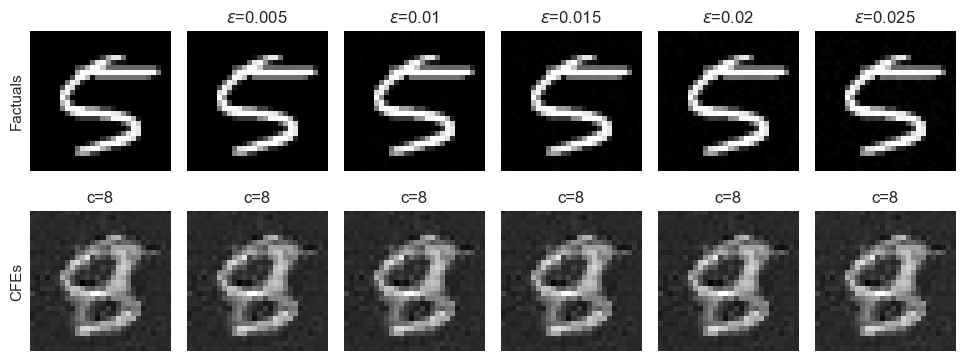

In [66]:
plt.style.use("seaborn-v0_8")

ind = 10
factuals_pert_list = [factuals_pert[noise_level][ind] for noise_level in noise_levels]
cfes_pert_list = [cfes_pert[noise_level][ind] for noise_level in noise_levels]

factuals_vis = [factuals[ind]] + factuals_pert_list #[factuals[0]] +
cfes_vis = [cfes[ind]] + cfes_pert_list #[cfes[0]] + 

n_rows = 2
n_cols = len(factuals_vis)

_, axs = plt.subplots(n_rows, n_cols, figsize=(10, 4), sharex=True, sharey=True)
for j in range(n_cols):
    axs[0, j].imshow(factuals_vis[j] , cmap="gray")
    if noise_levels and j > 0:
        noise = noise_levels[j-1]
        axs[0, j].set_title("$\\epsilon$={}".format(noise))

    axs[1, j].imshow(cfes_vis[j], cmap="gray")
    pred = tf.argmax(baseline_classifier.predict(tf.expand_dims(cfes_vis[j], axis=0), verbose=0), axis=1).numpy()
    axs[1, j].set_title(f'c={DESIRED_CLASS if pred == DESIRED_CLASS else pred[0]}')
    
    if j == 0:
        axs[0, j].set_ylabel('Factuals')
        axs[1, j].set_ylabel('CFEs')

plt.tight_layout()
plt.setp(plt.gcf().get_axes(), xticks=[], yticks=[]);
plt.show()

In [67]:
# Calculating L1 distance between the explanations of original and perturbed instances
l1_list = []
ssim_list = []


for i, noise_level in tqdm(enumerate(cfes_pert.keys())):
    l1_temp = []
    ssim_temp = []

    cfs_pert = cfes_pert[noise_level]

    for i in tqdm(range(cfes_pert[noise_level].shape[0])): 

        l1_distance = calculate_sparsity(cfes[i].flatten(), cfes_pert[noise_level][i].flatten()).item()
        l1_temp.append(l1_distance)

        ssim = calculate_ssim(torch.Tensor(cfes[i]).permute(2, 0, 1).unsqueeze(0), 
                              torch.Tensor(cfes_pert[noise_level][i]).permute(2, 0, 1).unsqueeze(0)).item()
        ssim_temp.append(ssim)

    print(f'Average Instability (L1) for the set of counterfactuals of size : {np.mean(l1_temp)}')    
    l1_list.append(l1_temp)
    
    print(f'Average SSIM for the set of counterfactuals of size : {np.mean(ssim_temp)}')    
    ssim_list.append(ssim_temp)

100%|██████████| 100/100 [00:00<00:00, 363.74it/s]
1it [00:00,  3.58it/s]

Average Instability (L1) for the set of counterfactuals of size : 1.3406975626945496
Average SSIM for the set of counterfactuals of size : 0.999741341471672


100%|██████████| 100/100 [00:00<00:00, 510.67it/s]
2it [00:00,  4.32it/s]

Average Instability (L1) for the set of counterfactuals of size : 2.6572260332107542
Average SSIM for the set of counterfactuals of size : 0.9989707070589066


100%|██████████| 100/100 [00:00<00:00, 658.27it/s]
3it [00:00,  5.07it/s]

Average Instability (L1) for the set of counterfactuals of size : 3.984585258960724
Average SSIM for the set of counterfactuals of size : 0.9976360356807709


100%|██████████| 100/100 [00:00<00:00, 587.78it/s]
4it [00:00,  5.34it/s]

Average Instability (L1) for the set of counterfactuals of size : 5.238809132575989
Average SSIM for the set of counterfactuals of size : 0.9958949446678161


100%|██████████| 100/100 [00:00<00:00, 651.40it/s]
5it [00:00,  5.19it/s]

Average Instability (L1) for the set of counterfactuals of size : 6.537939743995667
Average SSIM for the set of counterfactuals of size : 0.9935326099395752


In [68]:
with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_li_l1.pkl'), 'wb') as f:
    pickle.dump(l1_list, f)

with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_ssim.pkl'), 'wb') as f:
    pickle.dump(ssim_list, f)

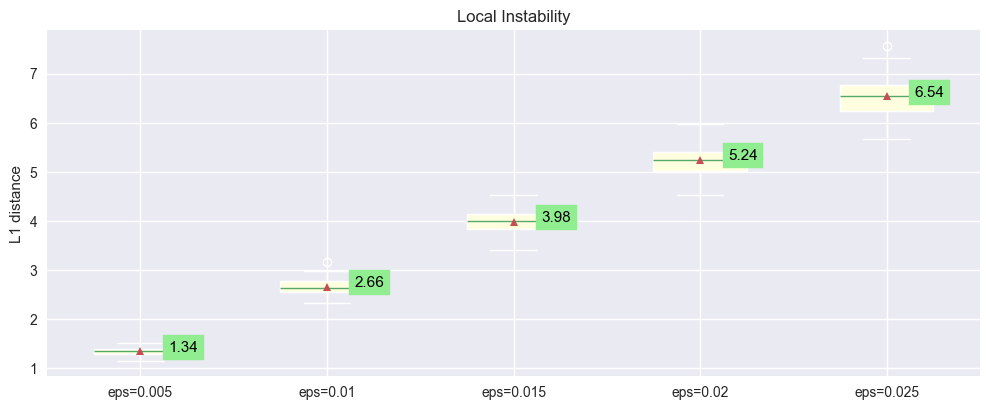

In [69]:
plt.style.use("seaborn-v0_8-notebook")
plt.rcParams['figure.figsize'] = [10, 4]

plot_boxplot(data=l1_list, mean_values=[np.round(np.mean(inst),2) for inst in l1_list],
             tick_labels=[f'eps={noise_level}' for noise_level in noise_levels],
             y_label='L1 distance', colors=['lightyellow'], title='Local Instability')

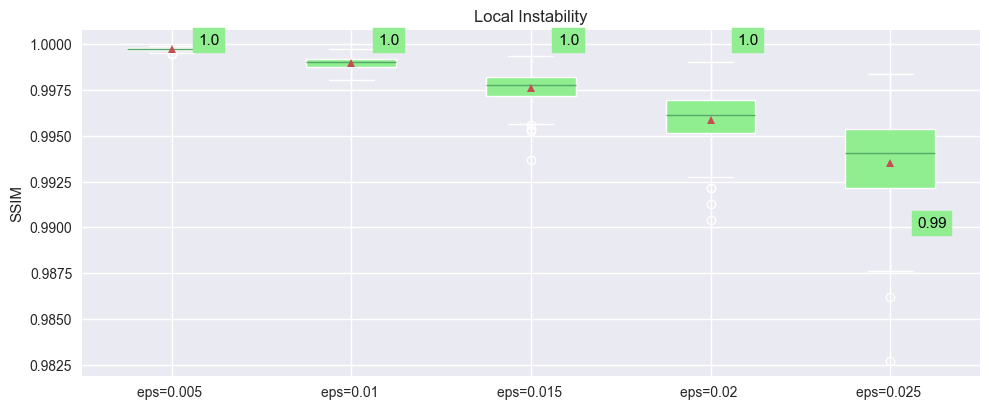

In [70]:
plot_boxplot(data=ssim_list, mean_values=[np.round(np.mean(inst),2) for inst in ssim_list],
             tick_labels=[f'eps={noise_level} ' for noise_level in noise_levels],

             y_label='SSIM', colors=['lightgreen'], title='Local Instability')

### Local Lipschitz Continuity

In [71]:
original_points = factuals
original_cfes = cfes
print("Are the lengths of initial points (factuals) and CFEs generated for them equal :", original_cfes.shape[0] == original_points.shape[0])


Are the lengths of initial points (factuals) and CFEs generated for them equal : True


In [72]:
noise_magnitude = 0.01

lip_estimates = []
n_samples = 30

for original_point, original_cfe in tqdm(zip(original_points[:30], original_cfes[:30])):

    neighbor_points = perturb_sample(original_point, n_samples=n_samples, 
                                     epsilon=noise_magnitude, type='uniform', 
                                     channels_first=False)  
    neighbor_points = neighbor_points.squeeze(0)  
    neighbor_cfes = generator.predict(neighbor_points, verbose=False)

    lip_estimate = 0
    for m, p in zip(neighbor_cfes, neighbor_points):
        num = np.linalg.norm((original_cfe - m).flatten(), ord=2) 
        denom = np.linalg.norm((original_point.numpy() - p).flatten(), ord=2)
        lip = num / denom
        lip_estimate = max(lip, lip_estimate)
 
    lip_estimates.append(lip_estimate)


30it [00:02, 13.66it/s]


In [73]:
with open(osp.join(output_dir, f'mnist_{DESIRED_CLASS}_lle.pkl'), 'wb') as f:
    pickle.dump(lip_estimates, f)

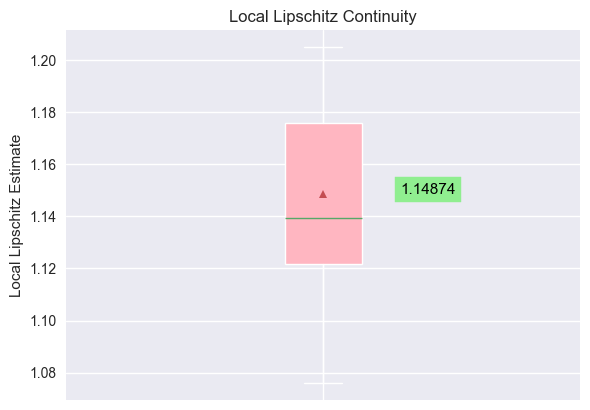

In [74]:
plt.rcParams['figure.figsize'] = [6, 4]
plot_boxplot(data=lip_estimates, mean_values=[np.round(np.mean(lip_estimates), 5)],
             tick_labels=[''],
             y_label='Local Lipschitz Estimate', colors=['lightpink'], title='Local Lipschitz Continuity')

### Invalidation Rate

Weights reinitialization

In [75]:
classifiers_weights_dir = r'D:\PycharmProjects\CF-Robustness-Benchmark\notebooks\experiments\mnist_classification\multi\checkpoints\mc_all_tf'

batch_size = 128

classifiers_list = []
for clf_fname in os.listdir(classifiers_weights_dir):
    cnn_perturbed = load_model(osp.join(classifiers_weights_dir, clf_fname), 
                            custom_objects={'CNNtf': CNNtf})
    classifiers_list.append(cnn_perturbed)

    logits = cnn_perturbed.predict(X_test)
    accuracy = (logits.argmax(axis=1) == y_test_red).mean()
    print(f"Classifier accuracy test: {accuracy:.3%}")

183/183 [==============================] - 1s 4ms/step
Classifier accuracy test: 98.957%
183/183 [==============================] - 1s 5ms/step
Classifier accuracy test: 97.315%
183/183 [==============================] - 1s 5ms/step
Classifier accuracy test: 98.837%
183/183 [==============================] - 1s 6ms/step
Classifier accuracy test: 97.383%
183/183 [==============================] - 1s 5ms/step
Classifier accuracy test: 97.742%
183/183 [==============================] - 1s 5ms/step
Classifier accuracy test: 98.580%
183/183 [==============================] - 1s 4ms/step
Classifier accuracy test: 97.007%
183/183 [==============================] - 1s 4ms/step
Classifier accuracy test: 98.923%
183/183 [==============================] - 1s 4ms/step
Classifier accuracy test: 97.640%
183/183 [==============================] - 1s 4ms/step
Classifier accuracy test: 98.409%


Evaluate IR only for the valid explanations for the baseline classifier

In [76]:
predictions = tf.argmax(baseline_classifier.predict(cfes, verbose=0), axis=1)
indices = np.where(predictions == DESIRED_CLASS)[0]
cfes_subsample = tf.gather(cfes, indices)

validity = len(np.where(predictions == DESIRED_CLASS)[0]) / len(cfes)
print(f'Validity of the generated CFEs for correctly classified instances: {validity:.2%}')

Validity of the generated CFEs for correctly classified instances: 38.00%


In [77]:
invalidation_rate_list = []
validity_list = []
total_cfs = cfes_subsample.shape[0]


for i, classifier in enumerate(classifiers_list):
    invalidation_rate = 0

    baseline_pred = tf.argmax(baseline_classifier.predict(cfes_subsample, verbose=0), axis=1)
    alternative_pred = tf.argmax(classifier.predict(cfes_subsample, verbose=0), axis=1)

    invalidation_rate_list.append(baseline_pred != alternative_pred)

inv_rate_array = np.asarray(invalidation_rate_list)
inv_rate_avg = inv_rate_array.mean(axis=0)
var_avg = 1 - inv_rate_array.mean(axis=0)
print("Average IR of the sample among {} models: {:.3f} ({:.3f})".format(len(classifiers_list), inv_rate_avg.mean(), inv_rate_avg.std()))
print("Average VaR of the sample among {} models: {:.3f} ({:.3f})".format(len(classifiers_list), var_avg.mean(), var_avg.std()))

Average IR of the sample among 10 models: 0.195 (0.164)
Average VaR of the sample among 10 models: 0.805 (0.164)


### Stability 

In [ ]:
k = 1000
sigma = 0.001

average_stability_list = []


for i, classifier in enumerate(classifiers_list):
    stability_list = []
    stability = 0

    original_logits = classifier.predict(cfes_subsample, verbose=0)
    # To calculate stability of only valid CFE, they need to be identified
    valid_cfs_ind = tf.where(original_logits.argmax(axis=1) == DESIRED_CLASS)[:, 0]
    original_logits_subsample = tf.gather(original_logits, valid_cfs_ind)

    original_probabilities = tf.nn.softmax(original_logits_subsample, axis=-1)[:, DESIRED_CLASS]

    valid_cfs_subsample = tf.gather(cfes_subsample, valid_cfs_ind)
    cf_sample_pert = perturb_sample(valid_cfs_subsample, n_samples=k, noise_magnitude=sigma)

    logits = classifier.predict(cf_sample_pert, verbose=0)
    # probabilities = tf.nn.softmax(logits,  axis=-1)[:, DESIRED_CLASS]
    probabilities = tf.nn.softmax(logits, axis=-1)[:, DESIRED_CLASS]

    for j in range(original_probabilities.shape[0]):
        original_probabilities_i = tf.expand_dims(original_probabilities[j], axis=-1)
        model_variance = abs(original_probabilities_i - probabilities[j*k : j*k+k])
        stability = (probabilities[j*k:j*k+k] - model_variance).numpy().mean()
        stability_list.append(stability)

    avg_i_stability = np.mean(stability_list)
    print(f'Average Stability of the model {i}: {round(avg_i_stability.item(), 3)} +- {round(np.std(stability_list).item(), 2)}')
    average_stability_list.append(avg_i_stability)


In [80]:
from numpy.random import multivariate_normal, uniform


def perturb_sample(
    input_images, n_samples=1, type="uniform", epsilon=0.01, channels_first=True, std=0.1
):
    """Generate perturbed samples around the input images.
    Args:
        input_images (numpy array): Input images to be perturbed.
        n_samples (int): Number of perturbed samples to generate per input image.
        type (str): Type of noise to add ('normal' or 'uniform').
        epsilon (float): Magnitude of the noise.
        channels_first (bool): Whether the input images have channels first format.
    Returns:
        numpy array: Perturbed samples of shape (batch_size, n_samples, height, width, channels) or (batch_size, n_samples, channels, height, width).
    """
    data = input_images
    if len(input_images.shape) == 3:
        data = np.expand_dims(input_images, axis=0)
    if channels_first:
        batch_size, height, width, channels = data.shape
        result_shape = (batch_size, n_samples, height, width, channels)
    else:
        batch_size, channels, height, width = data.shape
        result_shape = (batch_size, n_samples, channels, height, width)
    data = np.expand_dims(data, axis=1)
    data = np.tile(data, reps=[1, n_samples, 1, 1, 1])

    if type == "normal":
        # Define the mean and covariance for the multivariate normal distribution
        mean = np.zeros(channels * height * width)  # Zero mean for all pixels
        covariance = np.eye(channels * height * width) * std**2  # Diagonal covariance

        # Create the MultivariateNormal distribution
        noise = multivariate_normal(mean, covariance, size=(batch_size, n_samples))
        noise = noise.reshape(*result_shape)
        if epsilon > 0:
            noise = np.clip(noise, -epsilon, epsilon)

    elif type == "uniform":
        noise = uniform(-epsilon, epsilon, size=result_shape)

    # Perturb the input images with the generated noise and normalize to [0, 1]
    perturbed_data = data + noise
    perturbed_data = np.clip(perturbed_data, a_min=0, a_max=1)

    return perturbed_data

In [83]:
k = 1000
average_stability_list = []


for i, classifier in enumerate(classifiers_list):
    stability_list = []
    stability = 0

    original_logits = classifier.predict(cfes_subsample, verbose=0)
    # To calculate stability of only valid CFE, they need to be identified
    valid_cfs_ind = tf.where(original_logits.argmax(axis=1) == DESIRED_CLASS)[:, 0]
    print('Number of valid CFEs for the model {}: {}'.format(i, valid_cfs_ind.shape[0]))
    original_logits_subsample = tf.gather(original_logits, valid_cfs_ind)

    original_probabilities = tf.nn.softmax(original_logits_subsample, axis=-1)[:, DESIRED_CLASS]

    valid_cfs_subsample = tf.gather(cfes_subsample, valid_cfs_ind)
    cf_sample_pert = perturb_sample(valid_cfs_subsample, n_samples=k, 
                                    type='uniform', epsilon=0.01, std=1)

    for j in range(original_probabilities.shape[0]):
        cf_sample_pert_j = cf_sample_pert[j] 
        logits = classifier.predict(cf_sample_pert_j, verbose=0)
        probabilities = tf.nn.softmax(logits, axis=-1)[:, DESIRED_CLASS]

        original_probabilities_i = tf.expand_dims(original_probabilities[j], axis=-1)
        model_variance = abs(original_probabilities_i - probabilities)
        stability = (probabilities - model_variance).numpy().mean()
    
        stability_list.append(stability)

    avg_i_stability = np.mean(stability_list)
    print(f'Average Stability of the model {i}: {round(avg_i_stability.item(), 3)} +- {round(np.std(stability_list).item(), 2)}')
    average_stability_list.append(avg_i_stability)

Number of valid CFEs for the model 0: 37
Average Stability of the model 0: 0.162 +- 0.02
Number of valid CFEs for the model 1: 10
Average Stability of the model 1: 0.12 +- 0.01
Number of valid CFEs for the model 2: 33
Average Stability of the model 2: 0.179 +- 0.02
Number of valid CFEs for the model 3: 33
Average Stability of the model 3: 0.158 +- 0.02
Number of valid CFEs for the model 4: 37
Average Stability of the model 4: 0.175 +- 0.02
Number of valid CFEs for the model 5: 36
Average Stability of the model 5: 0.161 +- 0.03
Number of valid CFEs for the model 6: 32
Average Stability of the model 6: 0.137 +- 0.02
Number of valid CFEs for the model 7: 29
Average Stability of the model 7: 0.165 +- 0.03
Number of valid CFEs for the model 8: 26
Average Stability of the model 8: 0.136 +- 0.01
Number of valid CFEs for the model 9: 33
Average Stability of the model 9: 0.14 +- 0.02


In [84]:
print(f"Average stability : {round(np.mean(average_stability_list).item(), 3)} +- {round(np.std(average_stability_list).item(), 3)}")

Average stability : 0.153 +- 0.018


### LOF

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

In [ ]:
target_class_set = X_test[np.where(y_test_red==DESIRED_CLASS)[0]]
target_class_set.shape

TensorShape([974, 28, 28, 1])

In [ ]:
lof = LocalOutlierFactor(n_neighbors=5, novelty=True, p=1)
lof.fit(target_class_set.reshape(target_class_set.shape[0], -1))

target_class_ascores = lof.score_samples(cfes.reshape(cfes.shape[0], -1))
target_class_classes = np.where(target_class_ascores < -1.1, -1, 1)
print('Average negative LOF (the lower values the more anomaluous): {:.3f} +- {:.3f}'.format(np.mean(target_class_ascores), 
                                                                                            np.std(target_class_ascores)))

Average negative LOF (the lower values the more anomaluous): -1.665 +- 0.226


In [ ]:
lof = LocalOutlierFactor(n_neighbors=5, novelty=True, p=1)
lof.fit(X_test.reshape(X_test.shape[0], -1))

ascores = lof.score_samples(cfes.reshape(cfes.shape[0], -1))
aclasses = np.where(target_class_ascores < -1.2, -1, 1)
print('Average negative LOF (the lower values the more anomaluous): {:.3f} +- {:.3f}'.format(np.mean(ascores), np.std(ascores)))

Average negative LOF (the lower values the more anomaluous): -1.892 +- 0.311
